<a href="https://colab.research.google.com/github/siddhartha-sai-17/Anomaleydetection/blob/main/Anamoly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# =========================================
# CEIP CVR - Anomaly Prediction
# =========================================

# Core Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# System
import os
import warnings
warnings.filterwarnings("ignore")

# Sklearn - Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Sklearn - Model Selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    GridSearchCV
)

# Sklearn - Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Classical Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Advanced Models
from sklearn.ensemble import RandomForestClassifier

# Boosting Models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Display Settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
# =========================================
# Load Dataset
# =========================================

train_path = "/kaggle/input/competitions/ceip-ds-kaggle-cvr/train.parquet"
test_path = "/kaggle/input/competitions/ceip-ds-kaggle-cvr/test.parquet"
sample_path = "/kaggle/input/competitions/ceip-ds-kaggle-cvr/sample_submission.parquet"

# Read parquet files
train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)
sample_submission = pd.read_parquet(sample_path)

# Shape of datasets
print("Train Shape :", train_df.shape)
print("Test Shape  :", test_df.shape)

# Preview data
display(train_df.head())

# =========================================
# Basic Dataset Information
# =========================================

print("TRAIN INFO")
display(train_df.info())

print("\nMissing Values")
display(train_df.isnull().sum())

print("\nStatistical Summary")
display(train_df.describe())

print("\nTarget Distribution")
display(train_df['target'].value_counts())

print("\nTarget Percentage")
display(train_df['target'].value_counts(normalize=True) * 100)

Train Shape : (1639424, 7)
Test Shape  : (409856, 7)


,Date,X1,X2,X3,X4,X5,target
0,2020-12-16,1.518921,5.463154,1.0,2.718282,2.890372,0
1,2020-12-16,1.546509,5.458010,1.0,2.718282,2.833213,1
2,2020-12-16,1.645427,5.456560,1.0,7.389056,2.890372,1
3,2020-12-16,1.652022,5.458479,1.0,2.718282,2.890372,1
4,2020-12-16,1.695538,5.466709,1.0,2.718282,2.890372,0


TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1639424 entries, 0 to 1639423
Data columns (total 7 columns):
 #   Column  Non-Null Count    Dtype         
---  ------  --------------    -----         
 0   Date    1639424 non-null  datetime64[ns]
 1   X1      1639424 non-null  float64       
 2   X2      1639424 non-null  float64       
 3   X3      1639424 non-null  float64       
 4   X4      1639424 non-null  float64       
 5   X5      1639424 non-null  float64       
 6   target  1639424 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 87.6+ MB


None


Missing Values


...

,Date,X1,X2,X3,X4,X5
count,1639424,1.639424e+06,1.639424e+06,1.639424e+06,1.639424e+06,1.639424e+06
mean,2022-12-03 07:23:43.817145600,1.139258e+00,5.488189e+00,4.110388e+32,2.706323e+29,1.187219e+00
min,2020-12-16 00:00:00,1.000000e+00,5.412539e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,2021-12-10 00:00:00,1.049171e+00,5.480597e+00,1.000000e+00,1.000000e+00,0.000000e+00
50%,2022-11-30 00:00:00,1.105171e+00,5.488979e+00,1.000000e+00,1.000000e+00,6.931472e-01
75%,2023-11-23 00:00:00,1.214096e+00,5.496717e+00,1.000000e+00,2.718282e+00,2.890372e+00
max,2024-12-11 00:00:00,4.014850e+00,5.541852e+00,1.651636e+38,5.540622e+34,3.465736e+00
std,NaN,1.391992e-01,1.342811e-02,2.346156e+35,5.812988e+31,1.304814e+00



Target Distribution


target
0    1625386
1      14038
Name: count, dtype: int64


Target Percentage


target
0    99.143724
1     0.856276
Name: proportion, dtype: float64

In [ ]:
# =========================================
# Data Preprocessing
# =========================================

# Convert target to integer
train_df['target'] = train_df['target'].astype(int)

# Date Features
train_df['year'] = train_df['Date'].dt.year
train_df['month'] = train_df['Date'].dt.month
train_df['day'] = train_df['Date'].dt.day
train_df['dayofweek'] = train_df['Date'].dt.dayofweek

test_df['year'] = test_df['Date'].dt.year
test_df['month'] = test_df['Date'].dt.month
test_df['day'] = test_df['Date'].dt.day
test_df['dayofweek'] = test_df['Date'].dt.dayofweek

# Drop original Date column
train_df.drop('Date', axis=1, inplace=True)
test_df.drop('Date', axis=1, inplace=True)

print("Preprocessing completed!")

display(train_df.head())

Preprocessing completed!


,X1,X2,X3,X4,X5,target,year,month,day,dayofweek
0,1.518921,5.463154,1.0,2.718282,2.890372,0,2020,12,16,2
1,1.546509,5.458010,1.0,2.718282,2.833213,1,2020,12,16,2
2,1.645427,5.456560,1.0,7.389056,2.890372,1,2020,12,16,2
3,1.652022,5.458479,1.0,2.718282,2.890372,1,2020,12,16,2
4,1.695538,5.466709,1.0,2.718282,2.890372,0,2020,12,16,2


X1 Unique Values : 526
X2 Unique Values : 2812
X3 Unique Values : 88
X4 Unique Values : 81
X5 Unique Values : 32


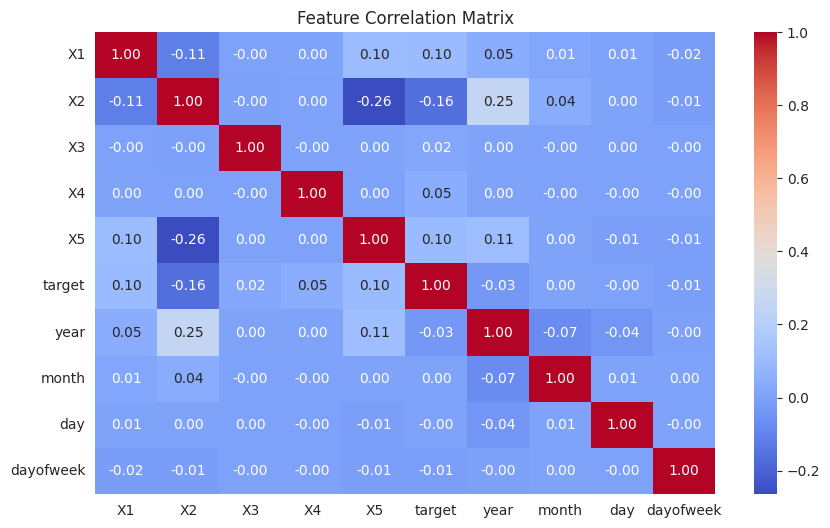

In [ ]:
# =========================================
# Feature Analysis
# =========================================

# Numerical Columns
num_cols = ['X1', 'X2', 'X3', 'X4', 'X5']

# Unique Values
for col in num_cols:
    print(f"{col} Unique Values : {train_df[col].nunique()}")

# Correlation Matrix
plt.figure(figsize=(10, 6))
sns.heatmap(
    train_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Feature Correlation Matrix")
plt.show()

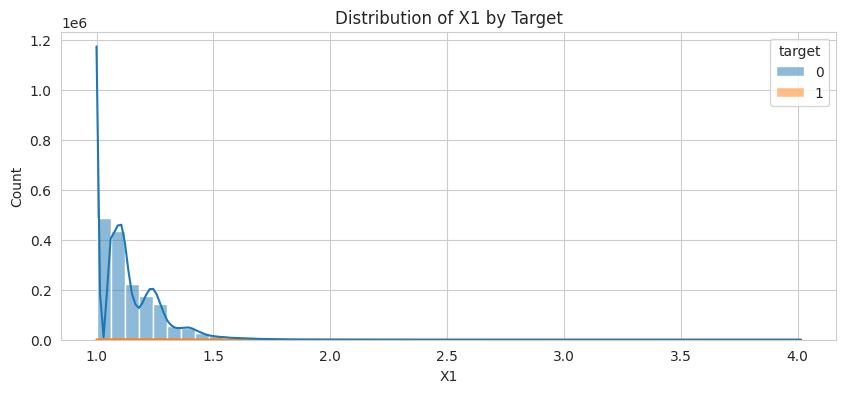

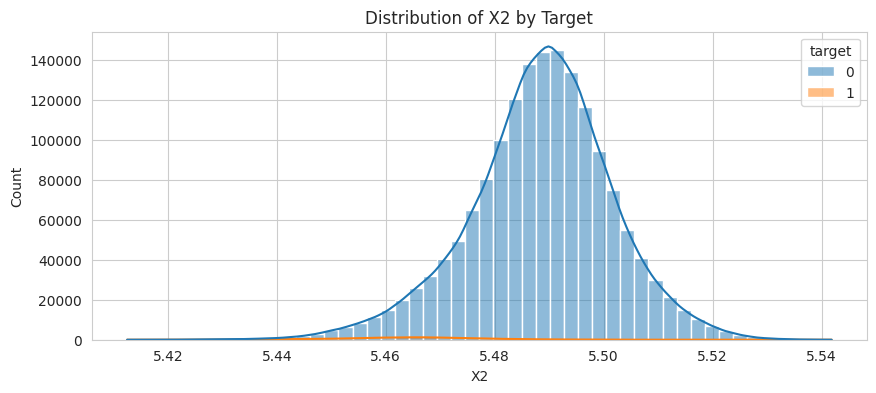

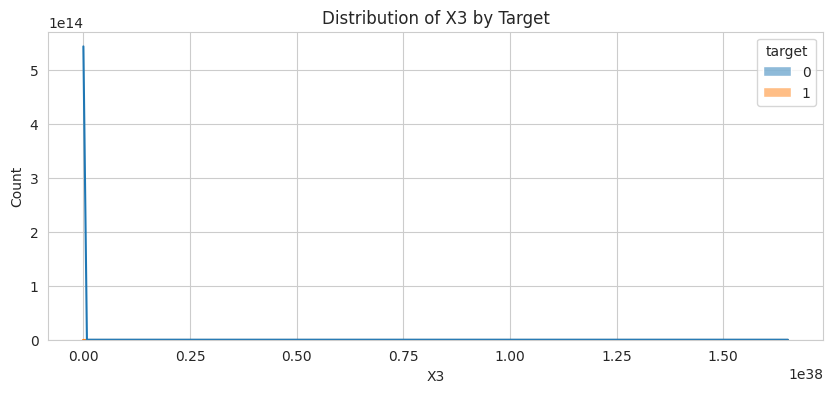

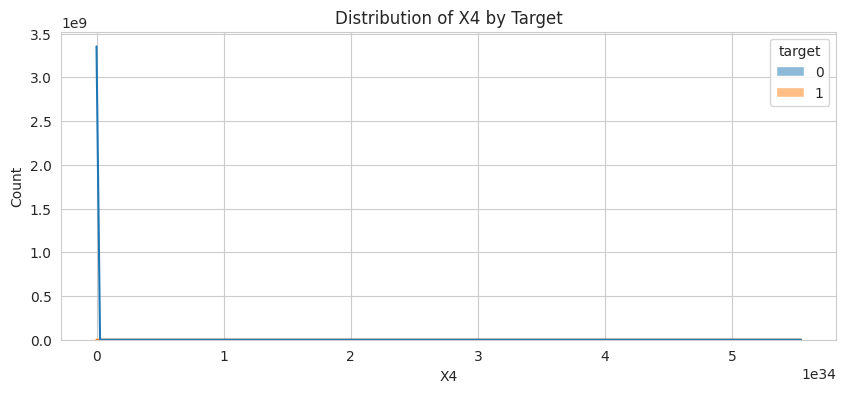

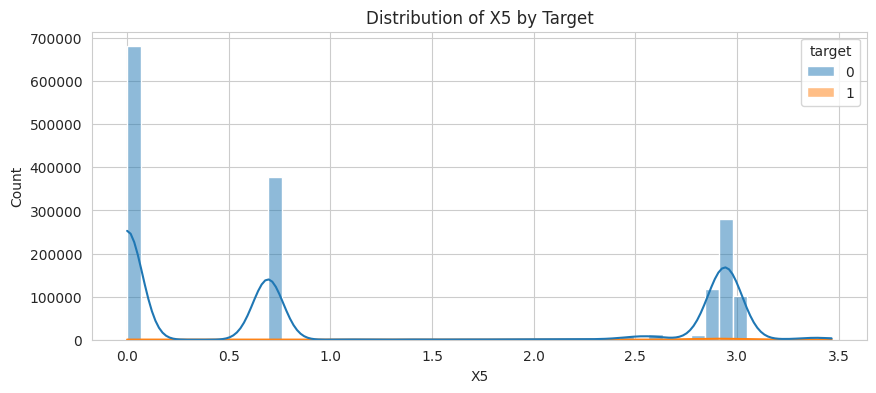

In [ ]:
# =========================================
# Distribution Analysis
# =========================================

features = ['X1', 'X2', 'X3', 'X4', 'X5']

for col in features:

    plt.figure(figsize=(10, 4))

    sns.histplot(
        data=train_df,
        x=col,
        hue='target',
        bins=50,
        kde=True
    )

    plt.title(f"Distribution of {col} by Target")
    plt.show()

In [ ]:
# =========================================
# Feature Engineering
# =========================================

# Avoid log(0)
epsilon = 1e-10

# Log Transformations
train_df['X3_log'] = np.log1p(train_df['X3'] + epsilon)
train_df['X4_log'] = np.log1p(train_df['X4'] + epsilon)

test_df['X3_log'] = np.log1p(test_df['X3'] + epsilon)
test_df['X4_log'] = np.log1p(test_df['X4'] + epsilon)

# Interaction Features
train_df['X1_X2'] = train_df['X1'] * train_df['X2']
train_df['X4_X5'] = train_df['X4'] * train_df['X5']

test_df['X1_X2'] = test_df['X1'] * test_df['X2']
test_df['X4_X5'] = test_df['X4'] * test_df['X5']

# Ratio Features
train_df['X1_X2_ratio'] = train_df['X1'] / (train_df['X2'] + epsilon)
test_df['X1_X2_ratio'] = test_df['X1'] / (test_df['X2'] + epsilon)

print("Feature Engineering Completed!")

display(train_df.head())

Feature Engineering Completed!


,X1,X2,X3,X4,X5,target,year,month,day,dayofweek,X3_log,X4_log,X1_X2,X4_X5,X1_X2_ratio
0,1.518921,5.463154,1.0,2.718282,2.890372,0,2020,12,16,2,0.693147,1.313262,8.298097,7.856845,0.278030
1,1.546509,5.458010,1.0,2.718282,2.833213,1,2020,12,16,2,0.693147,1.313262,8.440860,7.701472,0.283347
2,1.645427,5.456560,1.0,7.389056,2.890372,1,2020,12,16,2,0.693147,2.126928,8.978371,21.357119,0.301550
3,1.652022,5.458479,1.0,2.718282,2.890372,1,2020,12,16,2,0.693147,1.313262,9.017527,7.856845,0.302652
4,1.695538,5.466709,1.0,2.718282,2.890372,0,2020,12,16,2,0.693147,1.313262,9.269012,7.856845,0.310157


In [ ]:
# =========================================
# Train Validation Split
# =========================================

# Features and Target

# =========================================
# Train Validation Split
# =========================================

X = train_df.drop('target', axis=1)
y = train_df['target']

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Validation Shape :", X_valid.shape)

print("\nTraining Target Distribution")
print(y_train.value_counts(normalize=True))

print("\nValidation Target Distribution")
print(y_valid.value_counts(normalize=True))

Training Shape : (1311539, 14)
Validation Shape : (327885, 14)

Training Target Distribution
target
0    0.991438
1    0.008562
Name: proportion, dtype: float64

Validation Target Distribution
target
0    0.991436
1    0.008564
Name: proportion, dtype: float64


In [ ]:
# =========================================
# Time-Based Train Validation Split
# =========================================

# Re-load original data with Date
train_df = pd.read_parquet(train_path)

# Convert target
train_df['target'] = train_df['target'].astype(int)

# Date Features
train_df['year'] = train_df['Date'].dt.year
train_df['month'] = train_df['Date'].dt.month
train_df['day'] = train_df['Date'].dt.day
train_df['dayofweek'] = train_df['Date'].dt.dayofweek

# Feature Engineering
epsilon = 1e-10

train_df['X3_log'] = np.log1p(train_df['X3'] + epsilon)
train_df['X4_log'] = np.log1p(train_df['X4'] + epsilon)

train_df['X1_X2'] = train_df['X1'] * train_df['X2']
train_df['X4_X5'] = train_df['X4'] * train_df['X5']

train_df['X1_X2_ratio'] = train_df['X1'] / (train_df['X2'] + epsilon)

# TIME SPLIT
train_data = train_df[train_df['year'] < 2024]
valid_data = train_df[train_df['year'] == 2024]

# Drop Date
train_data = train_data.drop(columns=['Date'])
valid_data = valid_data.drop(columns=['Date'])

# Features and Target
X_train = train_data.drop('target', axis=1)
y_train = train_data['target']

X_valid = valid_data.drop('target', axis=1)
y_valid = valid_data['target']

print("Training Shape :", X_train.shape)
print("Validation Shape :", X_valid.shape)

print("\nTrain Target Distribution")
print(y_train.value_counts(normalize=True))

print("\nValidation Target Distribution")
print(y_valid.value_counts(normalize=True))

Training Shape : (1273392, 14)
Validation Shape : (366032, 14)

Train Target Distribution
target
0    0.990304
1    0.009696
Name: proportion, dtype: float64

Validation Target Distribution
target
0    0.99538
1    0.00462
Name: proportion, dtype: float64


In [ ]:
# =========================================
# Baseline Model - Logistic Regression
# =========================================

# Feature Scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

# Logistic Regression
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

# Train
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_valid_scaled)

# Evaluation
print("===== Logistic Regression =====")

print("Accuracy :", accuracy_score(y_valid, y_pred_lr))
print("Precision:", precision_score(y_valid, y_pred_lr))
print("Recall   :", recall_score(y_valid, y_pred_lr))
print("F1 Score :", f1_score(y_valid, y_pred_lr))

print("\nClassification Report\n")
print(classification_report(y_valid, y_pred_lr))

===== Logistic Regression =====
Accuracy : 0.9696474625169385
Precision: 0.12867618071434203
Recall   : 0.9651094027202839
F1 Score : 0.2270766662028663

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.97      0.98    364341
           1       0.13      0.97      0.23      1691

    accuracy                           0.97    366032
   macro avg       0.56      0.97      0.61    366032
weighted avg       1.00      0.97      0.98    366032



In [ ]:
# =========================================
# Random Forest Classifier
# =========================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train Model
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_valid)

# Evaluation
print("===== Random Forest =====")

print("Accuracy :", accuracy_score(y_valid, y_pred_rf))
print("Precision:", precision_score(y_valid, y_pred_rf))
print("Recall   :", recall_score(y_valid, y_pred_rf))
print("F1 Score :", f1_score(y_valid, y_pred_rf))

print("\nClassification Report\n")
print(classification_report(y_valid, y_pred_rf))

===== Random Forest =====
Accuracy : 0.9769692267342746
Precision: 0.1582310579166244
Recall   : 0.9225310467179184
F1 Score : 0.2701298701298701

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.98      0.99    364341
           1       0.16      0.92      0.27      1691

    accuracy                           0.98    366032
   macro avg       0.58      0.95      0.63    366032
weighted avg       1.00      0.98      0.98    366032



In [ ]:
# =========================================
# CatBoost Classifier
# =========================================

cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.05,
    depth=8,
    loss_function='Logloss',
    eval_metric='F1',
    class_weights=[1, 20],
    verbose=100,
    random_state=42
)

# Train
cat_model.fit(
    X_train,
    y_train,
    eval_set=(X_valid, y_valid),
    verbose=100
)

# Predictions
y_pred_cat = cat_model.predict(X_valid)

# Evaluation
print("\n===== CatBoost =====")

print("Accuracy :", accuracy_score(y_valid, y_pred_cat))
print("Precision:", precision_score(y_valid, y_pred_cat))
print("Recall   :", recall_score(y_valid, y_pred_cat))
print("F1 Score :", f1_score(y_valid, y_pred_cat))

print("\nClassification Report\n")
print(classification_report(y_valid, y_pred_cat))

0:	learn: 0.8673447	test: 0.8635177	best: 0.8635177 (0)	total: 398ms	remaining: 1m 58s
100:	learn: 0.8967415	test: 0.8966620	best: 0.8978502 (92)	total: 21.5s	remaining: 42.4s
200:	learn: 0.9095922	test: 0.8894368	best: 0.8978502 (92)	total: 42.7s	remaining: 21s
299:	learn: 0.9194863	test: 0.8839154	best: 0.8978502 (92)	total: 1m 3s	remaining: 0us

bestTest = 0.8978501573
bestIteration = 92

Shrink model to first 93 iterations.

===== CatBoost =====
Accuracy : 0.9872115006338243
Precision: 0.2555591890124264
Recall   : 0.9243051448846836
F1 Score : 0.40040988856154736

Classification Report

              precision    recall  f1-score   support

           0       1.00      0.99      0.99    364341
           1       0.26      0.92      0.40      1691

    accuracy                           0.99    366032
   macro avg       0.63      0.96      0.70    366032
weighted avg       1.00      0.99      0.99    366032



In [ ]:
# =========================================
# Threshold Optimization
# =========================================

# Probability Predictions
y_probs = cat_model.predict_proba(X_valid)[:, 1]

thresholds = np.arange(0.1, 1.0, 0.05)

best_threshold = 0
best_f1 = 0

print("Threshold | F1 Score")
print("-" * 25)

for threshold in thresholds:

    y_pred_threshold = (y_probs >= threshold).astype(int)

    score = f1_score(y_valid, y_pred_threshold)

    print(f"{threshold:.2f}      | {score:.4f}")

    if score > best_f1:
        best_f1 = score
        best_threshold = threshold

print("\nBest Threshold :", best_threshold)
print("Best F1 Score  :", best_f1)

Threshold | F1 Score
-------------------------
0.10      | 0.1567
0.15      | 0.2035
0.20      | 0.2329
0.25      | 0.2584
0.30      | 0.2857
0.35      | 0.3129
0.40      | 0.3376
0.45      | 0.3674
0.50      | 0.4004
0.55      | 0.4260
0.60      | 0.4570
0.65      | 0.4898
0.70      | 0.5316
0.75      | 0.5700
0.80      | 0.6056
0.85      | 0.6431
0.90      | 0.6616
0.95      | 0.6146

Best Threshold : 0.9000000000000002
Best F1 Score  : 0.6616343944863801


In [ ]:
# =========================================
# Final Evaluation with Best Threshold
# =========================================

# Final Predictions
final_preds = (y_probs >= best_threshold).astype(int)

print("===== Optimized CatBoost =====")

print("Accuracy :", accuracy_score(y_valid, final_preds))
print("Precision:", precision_score(y_valid, final_preds))
print("Recall   :", recall_score(y_valid, final_preds))
print("F1 Score :", f1_score(y_valid, final_preds))

print("\nClassification Report\n")
print(classification_report(y_valid, final_preds))

===== Optimized CatBoost =====
Accuracy : 0.9971833063775845
Precision: 0.7433628318584071
Recall   : 0.5960969840331165
F1 Score : 0.6616343944863801

Classification Report

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    364341
           1       0.74      0.60      0.66      1691

    accuracy                           1.00    366032
   macro avg       0.87      0.80      0.83    366032
weighted avg       1.00      1.00      1.00    366032



In [ ]:
# =========================================
# Correct Kaggle Submission
# =========================================

# Predict probabilities
test_probs = cat_model.predict_proba(test_df)[:, 1]

# Apply optimized threshold
test_preds = (test_probs >= best_threshold).astype(int)

# Create submission
submission = pd.DataFrame({
    'ID': range(len(test_preds)),
    'target': test_preds
})

# Save CSV
submission.to_csv("submission.csv", index=False)

print("Submission file created successfully!")

display(submission.head())
print(submission.shape)

Submission file created successfully!


,ID,target
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


(409856, 2)
